# 09 — Concept Activation Vectors (CAV/TCAV) for Case 1

Implements Kim et al. 2018's TCAV method on Case 1's trained multi-task
Transformer: define a concept via labeled positive/negative example
windows, fit a linear probe (Concept Activation Vector) in the model's
pooled 128-dim representation, then measure how sensitive each class's
logit is to moving along that direction.

**Scope**: label-derived concepts (built from the true movement labels
already on disk), not literature-derived ones yet — see
[docs/interpretability-methods-notes.md §4.1](../docs/interpretability-methods-notes.md#41-a-neurolens-rag-specific-variant-literature-derived-concept-hypotheses)
for why literature-derived concepts are a harder, still-open problem. This
validates the TCAV mechanism against ground truth first.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders
from neurolens.engine import get_device
from neurolens.model_builder import TransformerDecoder
from neurolens.concepts import CONCEPT_DEFINITIONS, run_concept_analysis

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "exp4_transformer_multitask" / "best.pt"

device = get_device()
train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=64)

model = TransformerDecoder(
    num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True
)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

class_names = [info["class_to_condition"][str(c)] for c in range(info["num_classes"])]
print("classes:", class_names)
print("concepts:", list(CONCEPT_DEFINITIONS.keys()))


classes: ['baseline', 'left_hand', 'right_hand', 'left_foot', 'right_foot', 'tongue']
concepts: ['hand', 'foot', 'tongue', 'right_side', 'left_side']


## 1. Fit each concept's CAV and score TCAV sensitivity per class

In [2]:
results = run_concept_analysis(model, train_loader, test_loader, device, class_names)

for concept, r in results.items():
    print(f"{concept:12s} probe_accuracy={r['probe_accuracy']:.3f}  n_train={r['n_train_examples']}")


hand         probe_accuracy=0.998  n_train=3556
foot         probe_accuracy=0.997  n_train=3556
tongue       probe_accuracy=1.000  n_train=3556
right_side   probe_accuracy=0.999  n_train=2268
left_side    probe_accuracy=0.999  n_train=2268


## 2. Visualize as a concept x class heatmap

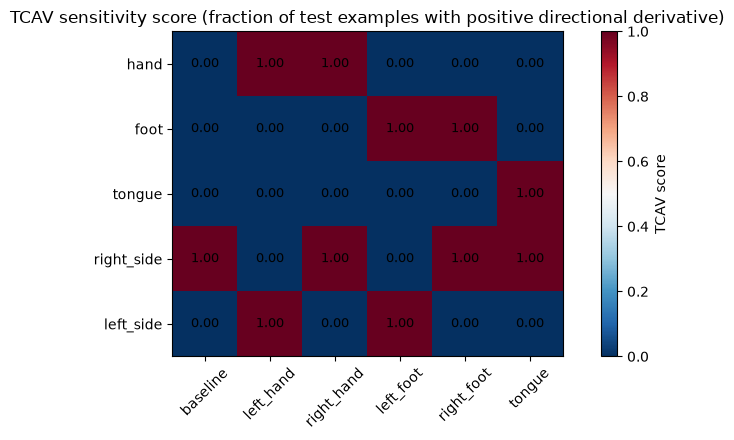

In [3]:
concept_names = list(results.keys())
score_matrix = np.array([[results[c]["scores"][cls] for cls in class_names] for c in concept_names])

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(score_matrix, cmap="RdBu_r", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(len(concept_names)))
ax.set_yticklabels(concept_names)
ax.set_title("TCAV sensitivity score (fraction of test examples with positive directional derivative)")
for i in range(len(concept_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{score_matrix[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="TCAV score")
fig.tight_layout()
plt.show()


## 3. Reading the result

The effector concepts (`hand`, `foot`, `tongue`) each show the expected clean pattern: TCAV score of 1.0 exactly for the classes that define the concept's positive set, 0.0 for everything else, with near-perfect probe accuracy (>0.99) — the representation's directions genuinely correspond to these human-interpretable concepts, not just to linear separability of the raw classification task.

**The laterality concepts (`right_side`, `left_side`) reveal something worth being precise about, not glossing over.** Both were fit only on lateralized classes (`right_hand`/`right_foot` vs. `left_hand`/`left_foot`) — `baseline` and `tongue` were never part of either concept's training set. Yet both `baseline` and `tongue` score 1.0 on `right_side` and 0.0 on `left_side`. Since the two directions are fit as literal opposites (swapped positive/negative labels), this isn't two independent findings — it's one: the linear laterality direction learned only from lateralized movements happens to place `baseline` and `tongue` representations on its "right" pole. That is **not evidence the model treats baseline or tongue as right-lateralized** — it's a known limitation of linear CAV probes: a direction fit on a subset of classes can extrapolate in an arbitrary but directionally consistent way onto classes outside that subset, and there's no guarantee the extrapolation is meaningful. Worth remembering before trusting any CAV score on inputs outside the concept's training distribution.
